# 전체 파이프라인 구조
Query   
. . . ↓   
Rewrite       ← 질문을 검색에 최적화된 형태로 재작성       
. . . ↓   
Retrieve      ← Pinecone에서 관련 문서 검색       
. . . ↓    
Grade         ← 검색된 문서의 품질 평가     
. . . ├─ good   → Generate → 답변 출력       
. . . ├─ bad (retry < 2) → rewrite_retry → Retrieve (루프)       
. . . └─ bad (retry ≥ 2) → Fallback → 경고 포함 답변 출력          

# 실습 예제

| 제목 | 내용 | 비고 |
| :--- | :--- | :--- |
| 문서 | 2026년 2월 한국은행 경제전망보고서 | (93페이지, 249청크) |
| 벡터 DB | Pinecone (finance-bok / bok-ns1) | @금융도메인 래그 질의 실습 |
| 임베딩 | text-embedding-3-small (1536차원) | |
| LLM | gpt-4o-mini (temperature=0) | |
| LangGraph | 1.1.6 | |


## step 1 - import 및 초기화

In [10]:
from dotenv import load_dotenv
import os
load_dotenv(r"D:\Practice\hipython\llm\.env", override=True)

# LlamaIndex
from pinecone import Pinecone
from llama_index.core import VectorStoreIndex, Settings
from llama_index.embeddings.openai import OpenAIEmbedding
from llama_index.vector_stores.pinecone import PineconeVectorStore
from llama_index.llms.openai import OpenAI

# 1. LLM & Embedding 설정
Settings.embed_model = OpenAIEmbedding(
    model="text-embedding-3-small"
)

Settings.llm = OpenAI(
    model="gpt-4o-mini",
    temperature=0
)

# 2. Pinecone 연결
pc = Pinecone(api_key=os.environ["PINECONE_API_KEY"])
pinecone_index = pc.Index("finance-bok-table")

# 3. Index 생성 (이미 저장된 데이터 사용)
vector_store = PineconeVectorStore(
    pinecone_index=pinecone_index,
    namespace="bok-ns-t"   # 🔥 반드시 동일하게
)
index = VectorStoreIndex.from_vector_store(vector_store)

# query_engine = index.as_query_engine(
#     similarity_top_k=3
# )

# for compatibilty
retriever = index.as_retriever(similarity_top_k=3)

print("초기화 완료 (LlamaIndex)")

초기화 완료 (LlamaIndex)


## Step 2 - State 정의
- State : 파이프라인 설계도
- doc_grade와 retry_count가 함께 있어야 품질 판단 + 무한루프 방지가 동시에 가능

In [2]:
from typing import TypedDict, List
from llama_index.core.schema import NodeWithScore
# from langchain_core.documents import Document

class FinanceRAGState(TypedDict):
    query:           str            # 사용자 원본 질문
    rewritten_query: str            # 재작성된 검색 질문
    # docs:            List[Document] # 검색된 문서
    docs:            List[NodeWithScore] # 검색된 문서
    answer:          str            # 최종 답변
    retry_count:     int            # 재시도 횟수 (최대 2회) 
    doc_grade:       str            # 문서 품질 평가 결과 ("good" / "bad")

## Step 3 — Node 5개 정의

### Node 1: Query Rewrite
- 사용자의 질문을 검색에 적합한 형태로 정제

In [3]:
# Node ① Query Rewrite
from llama_index.llms.openai import OpenAI
from llama_index.core import VectorStoreIndex, Settings

llm = Settings.llm
# llm = OpenAI(model="gpt-4o-mini", temperature=0)

def rewrite_node(state: FinanceRAGState):
    
    prompt = f"""
        당신은 금융 검색 전문가입니다.
        사용자의 질문을 한국은행 경제전망 보고서 검색에 최적화된 형태로 재작성하세요.
        재작성된 질문만 출력하세요.
        
        질문:
        {state["query"]}
    """
    
    response = llm.complete(prompt)
    rewritten = str(response).strip()

    print(f"[rewrite] {rewritten}")
    
    return {
        "rewritten_query": rewritten,
        "retry_count": state.get("retry_count", 0)
    }

### Node 2: Retrieve 
- 정제된 질문을 기반으로 문서를 검색

In [15]:
# Node ② Retrieve

# for compatibilty
# retriever = index.as_retriever(similarity_top_k=3)

def retrieve_node(state: FinanceRAGState):
    docs = retriever.retrieve(state["rewritten_query"])
    print(f"[retrieve] {len(docs)}개 문서 검색")
    return {"docs": docs}

### Node 3: Grade - 문서 품질 평가

### Node 3: Generate Node
- 검색된 문서를 바탕으로 최종 답변을 생성

In [20]:
# Node ③ Grade
def grade_node(state: FinanceRAGState):
    
    context = "\n\n".join([doc.node.text for doc in state["docs"]])
    prompt = f"""
        당신은 검색 문서의 품질을 평가하는 전문가입니다.
        아래 질문과 검색된 문서를 보고 문서가 질문에 답변하기에 충분한지 평가하세요.

        출력 규칙:
        - 충분하면 "good"
        - 불충분하면 "bad"
        - 다른 말은 절대 출력하지 마세요

        질문:
        {state["query"]}
        
        [검색된 문서]:
        {context}
    """
    
    response = llm.complete(prompt)
    grade = str(response).strip().lower()
    
    print(f"[grade] 품질 평가 결과: {grade} (재시도 횟수: {state.get('retry_count', 0)})")
    return {"doc_grade": grade}

### Node 4: Generate - 답변 생성

In [5]:
# Node ④ Generate

def generate_node(state: FinanceRAGState):
    context = "\n\n".join([doc.node.text for doc in state["docs"]])
    prompt = f"""
        당신은 한국은행 경제전망 보고서 전문 애널리스트입니다.

        아래 참고 문서를 바탕으로 질문에 정확하게 답하세요.
        문서에 없는 내용은 반드시 "보고서에서 확인되지 않습니다"라고 답하세요.

        [참고 문서]
        {context}

        [질문]
        {state["query"]}

        한글로 간결하고 정확하게 답변하세요.
    """
    
    response = llm.complete(prompt)
    answer = str(response).strip()
    
    print(f"[generate] 답변 생성 완료")
    return {"answer": answer}

### Node 5: Retry  — 카운터 증가 + 질문 재작성

In [6]:
# Node ⑤ Retry
def rewrite_retry_node(state: FinanceRAGState):
    retry     = state.get("retry_count", 0) + 1
    
    prompt = f"""
        이전 검색 결과가 충분하지 않았습니다.
        더 구체적이고 검색에 최적화된 질문으로 다시 작성하세요.

        질문:
        {state["query"]}

        출력:
        재작성된 질문만 출력하세요.
    """

    response = llm.complete(prompt)
    rewritten = str(response).strip()
    
    print(f"[rewrite_retry] 재시도 {retry}회 → {rewritten}")
    return {
        "rewritten_query": rewritten,
        "retry_count":     retry
    }

### Node 6: Fallback — 재시도 초과 시 안전 답변

In [7]:
# Node ⑥ Fallback
def fallback_node(state: FinanceRAGState):

    print(f"[fallback] 재시도 초과 → 일반 답변 생성")

    context = "\n\n".join([
        f"(p.{doc.node.metadata.get('page', '')}) {doc.node.text[:500]}"
        for doc in state["docs"]
    ])

    prompt = f"""
        다음 문서를 참고하여 질문에 답하세요.

        단, 문서가 충분하지 않을 수 있으므로
        불확실한 경우 추측하지 말고 "보고서에서 확인되지 않습니다"라고 답하세요.

        [참고 문서]
        {context}

        [질문]
        {state["query"]}
    """

    response = llm.complete(prompt)
    answer = str(response).strip()

    return {
        "answer": f"[참고: 검색 품질이 낮을 수 있습니다]\n{answer}"
    }

### 조건 함수 - Grade 결과 + 재시도 횟수로 분기

In [12]:
def route_after_grade(state: FinanceRAGState) -> str:
    if state["doc_grade"] == "good":
        return "generate"

    retry = state.get("retry_count", 0)
    if retry >= 2:
        return "fallback"

    return "rewrite_retry"

## Step 4 - Graph 구성 (Node와 Edge 연결)

- 정의한 Node들을 그래프로 연결
- 실행 순서를 코드로 직접 호출하지 않고, Node 간의 흐름 구조를 선언적으로 정의
- StateGraph : 노드 간에 데이터를 주고받는 공유 메모리

In [21]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(FinanceRAGState)

# Node 등록
graph.add_node("rewrite",       rewrite_node)
graph.add_node("retrieve",      retrieve_node)
graph.add_node("grade",         grade_node)
graph.add_node("generate",      generate_node)
graph.add_node("fallback",      fallback_node)
graph.add_node("rewrite_retry", rewrite_retry_node)

# Edge 연결
graph.add_edge(START,      "rewrite")
graph.add_edge("rewrite",  "retrieve")
graph.add_edge("retrieve", "grade")

# 조건 분기 — grade 이후
graph.add_conditional_edges(
    "grade",
    route_after_grade,
    {
        "generate":      "generate",
        "rewrite_retry": "rewrite_retry",
        "fallback":      "fallback"
    }
)

# 재시도 루프
graph.add_edge("rewrite_retry", "retrieve")

# 종료
graph.add_edge("generate", END)
graph.add_edge("fallback",  END)

gapp = graph.compile()
print("Graph 컴파일 완료")

Graph 컴파일 완료


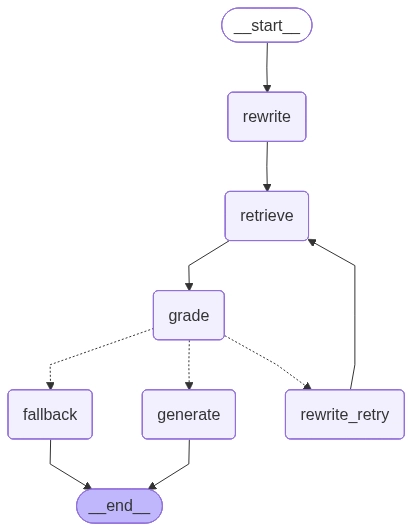

## Step 5 - 실행 테스트 : 조건 기반 Routing (State를 이용한 실행 분기)

Query → Rewrite → Retrieve                   
. . . . . . . . . . . . . . . . . . . .  ├─ (docs > 2) → Compress → Generate                 
. . . . . . . . . . . . . . . . . . . .  └─ (docs ≤ 2) → Generate              

### 테스트 1 - 보고서 내 질문 (grade: good 예상)

In [22]:
initial_state = {
    "query":       "2026년 GDP 성장률 전망치는 얼마인가요?",
    "retry_count": 0
}
final = gapp.invoke(initial_state)
print(f"\n[ 최종 답변 ]\n{final['answer']}")

[rewrite] 2026년 한국은행 경제전망 보고서에 따른 GDP 성장률 전망치는 얼마인가요?
[retrieve] 3개 문서 검색
[grade] 품질 평가 결과: bad (재시도 횟수: 0)
[rewrite_retry] 재시도 1회 → 2026년 한국의 GDP 성장률 전망치는 얼마인가요?
[retrieve] 3개 문서 검색
[grade] 품질 평가 결과: good (재시도 횟수: 1)
[generate] 답변 생성 완료

[ 최종 답변 ]
2026년 GDP 성장률 전망치는 2.0%입니다.


### 테스트 2 - 보고서 범위 밖 질문 (grade: bad → 재시도 → fallback)

In [23]:
initial_state = {
    "query":       "2030년 한국 부동산 시장 전망은?",
    "retry_count": 0
}
final = gapp.invoke(initial_state)
print(f"\n[ 최종 답변 ]\n{final['answer']}")

[rewrite] 2030년 한국 부동산 시장에 대한 한국은행 경제전망 보고서의 예측은 무엇인가요?
[retrieve] 3개 문서 검색
[grade] 품질 평가 결과: bad (재시도 횟수: 0)
[rewrite_retry] 재시도 1회 → 2030년 한국 부동산 시장의 전망과 주요 영향을 미칠 요인은 무엇인가요?
[retrieve] 3개 문서 검색
[grade] 품질 평가 결과: bad (재시도 횟수: 1)
[rewrite_retry] 재시도 2회 → 2030년 한국 부동산 시장의 전망과 주요 영향을 미치는 요인은 무엇인가요?
[retrieve] 3개 문서 검색
[grade] 품질 평가 결과: bad (재시도 횟수: 2)
[fallback] 재시도 초과 → 일반 답변 생성

[ 최종 답변 ]
[참고: 검색 품질이 낮을 수 있습니다]
보고서에서 확인되지 않습니다.
